<a href="https://colab.research.google.com/github/FrankEHA/INGENIERIA_DEL_CONOCIMIENTO/blob/main/EJERCICIO3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 3 — Dataset Propio: Predicción de Churn en Telecomunicaciones

**Paso 0 — Configuración del entorno.** Importamos todas las librerías necesarias para el análisis: manejo de datos, visualización y los modelos de machine learning que vamos a usar.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    ConfusionMatrixDisplay, RocCurveDisplay
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

def eval_classifier(model, X_tr, y_tr, X_te, y_te, model_name='Modelo'):
    """Evalúa un clasificador: métricas, matriz de confusión y reporte."""
    y_pred = model.predict(X_te)

    metrics = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred),
        'F1-Score':  f1_score(y_te, y_pred)
    }

    print(f'=== {model_name} ===')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['No churn', 'Churn'],
                yticklabels=['No churn', 'Churn'])
    axes[0].set_title(f'Matriz de Confusión — {model_name}')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')

    tn, fp, fn, tp = cm.ravel()
    labels = ['TN\n(no churn\ncorrecto)', 'FP\n(no churn→\nchurn)',
              'FN\n(churn→\nno churn)', 'TP\n(churn\ncorrecto)']
    values = [tn, fp, fn, tp]
    bar_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
    axes[1].bar(labels, values, color=bar_colors)
    axes[1].set_title(f'Desglose — {model_name}')
    axes[1].set_ylabel('Cantidad')

    plt.tight_layout()
    plt.show()

    print(f'\n  FN (churn no detectado): {fn}')
    print(f'  FP (no churn predicho como churn): {fp}')
    print(f'\nReporte completo:')
    print(classification_report(y_te, y_pred,
          target_names=['No churn', 'Churn']))

    return metrics

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


**Paso 1 — Instalación y descarga del dataset.**
Instalamos kagglehub y descargamos el dataset de Telecom Churn desde Kaggle.

In [16]:
!pip install kagglehub -q
import kagglehub

path = kagglehub.dataset_download("barun2104/telecom-churn")
print("Path to dataset files:", path)

import os
print(os.listdir(path))

# Alternativa si falla la autenticación:
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

Using Colab cache for faster access to the 'telecom-churn' dataset.
Path to dataset files: /kaggle/input/telecom-churn
['telecom_churn.csv']


**Paso 2 — Carga del dataset.**
Leemos el CSV descargado y lo cargamos en un DataFrame de pandas.

In [17]:
import glob

csv_file = glob.glob(f'{path}/*.csv')[0]
df = pd.read_csv(csv_file)

print(f'Dataset: {df.shape[0]} muestras, {df.shape[1]-1} features')
df.head()

Dataset: 3333 muestras, 10 features


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


**Paso 3 — Exploración inicial.** Revisamos tipos de datos, valores nulos y la distribución de la variable objetivo (Churn) para confirmar que no hay datos faltantes y ver qué tan desbalanceadas están las clases.

In [18]:
print(df.info())
print('\nValores nulos por columna:')
print(df.isna().sum())
print('\nDistribución de clases (Churn):')
print(df['Churn'].value_counts())
print(f'\nProporción de churn: {df["Churn"].mean():.1%}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB
None

Valores nulos por columna:
Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
OverageFee         0


**Paso 4 — Distribución de clases.** Visualizamos la proporción de clientes que se dieron de baja (churn) frente a los que se quedaron, en barras y en pie chart, igual que en el ejemplo original.

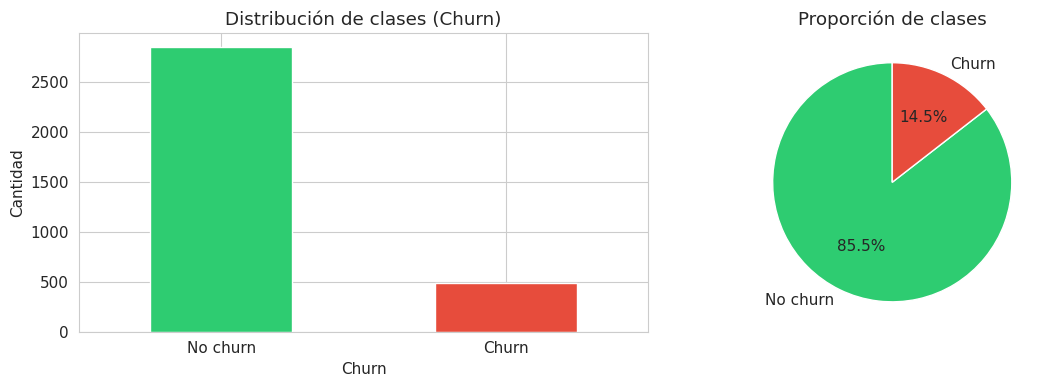

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors2 = ['#2ecc71', '#e74c3c']
df['Churn'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=colors2)
axes[0].set_title('Distribución de clases (Churn)')
axes[0].set_xticklabels(['No churn', 'Churn'], rotation=0)
axes[0].set_ylabel('Cantidad')

df['Churn'].value_counts().plot(kind='pie', ax=axes[1], colors=colors2,
    autopct='%1.1f%%', startangle=90, labels=['No churn', 'Churn'])
axes[1].set_ylabel('')
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

**Paso 5 — Distribución de features clave por clase.** Comparamos, mediante histogramas superpuestos, cómo se distribuyen algunas variables numéricas relevantes según si el cliente se dio de baja o no.

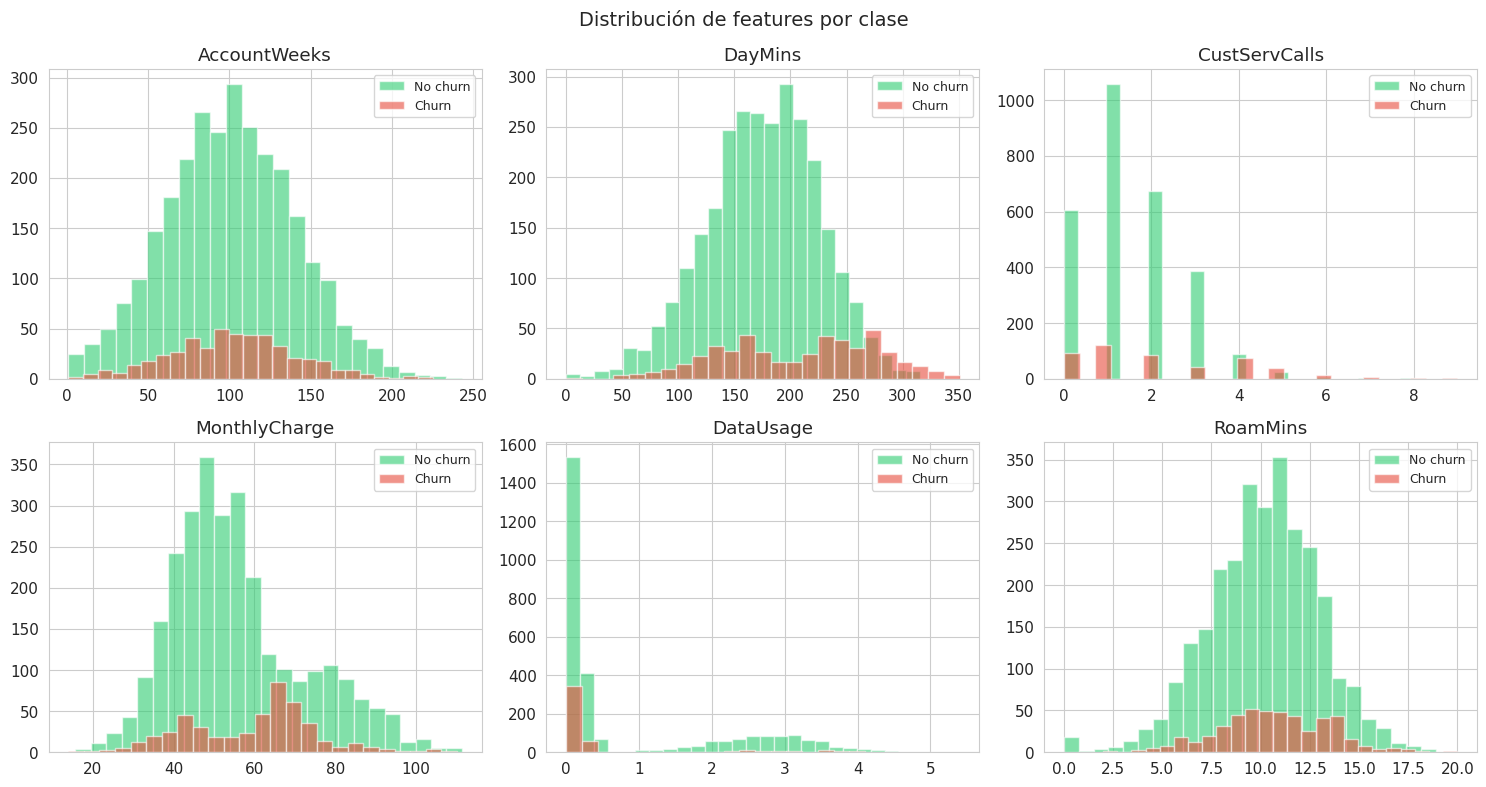

In [20]:
key_features = ['AccountWeeks', 'DayMins', 'CustServCalls',
                 'MonthlyCharge', 'DataUsage', 'RoamMins']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(key_features):
    ax = axes[i//3, i%3]
    for label, color in zip([0, 1], colors2):
        subset = df[df['Churn'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label='No churn' if label == 0 else 'Churn')
    ax.set_title(feat)
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features por clase', fontsize=14)
plt.tight_layout()
plt.show()

**Paso 6 — Matriz de correlación.** Vemos qué tan relacionadas están las variables numéricas entre sí y con el target, para detectar posibles redundancias o predictores fuertes.

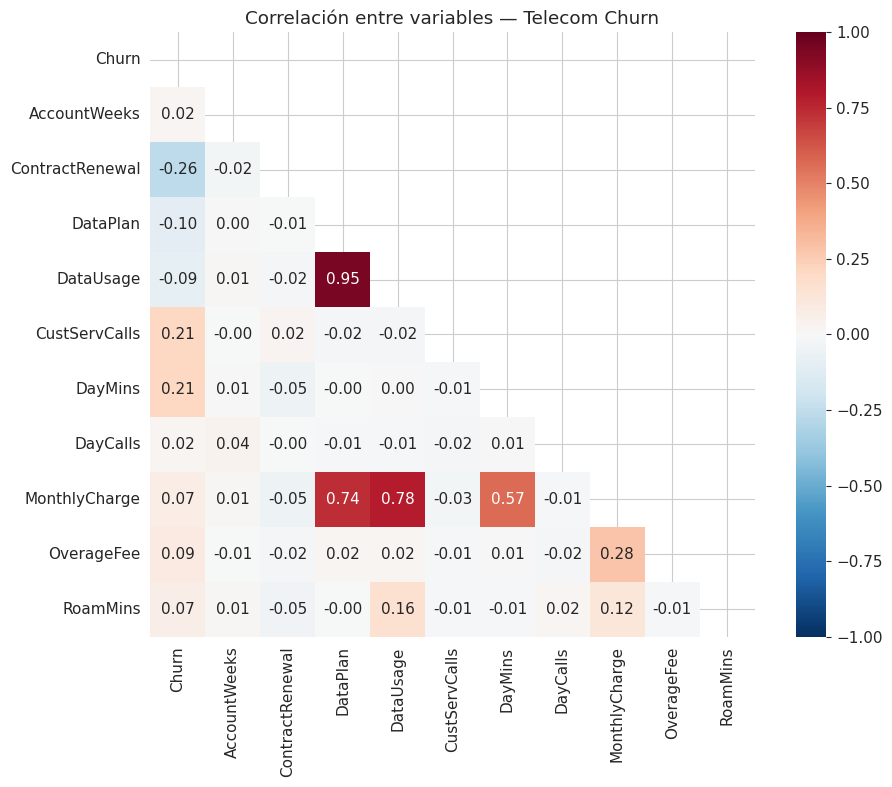

In [21]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlación entre variables — Telecom Churn')
plt.tight_layout()
plt.show()

**Paso 7 — Preparación de datos.** Separamos features (X) y target (y), dividimos en entrenamiento/test de forma estratificada (para mantener la proporción de churn en ambos conjuntos), y configuramos la validación cruzada estratificada.

In [22]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Test:          {X_test.shape[0]} muestras')
print(f'Proporción churn en train: {y_train.mean():.1%}')
print(f'Proporción churn en test:  {y_test.mean():.1%}')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Entrenamiento: 2666 muestras
Test:          667 muestras
Proporción churn en train: 14.5%
Proporción churn en test:  14.5%


**Paso 8 — Entrenamiento de los 5 modelos.** Armamos los pipelines de Regresión Logística, Árbol de Decisión, SVM, KNN y Random Forest (el modelo adicional), usando class_weight='balanced' donde aplica, ya que el churn suele estar desbalanceado.

In [23]:
from sklearn.ensemble import RandomForestClassifier

models = {
    'Regresión Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'Árbol de Decisión': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                        min_samples_leaf=5, class_weight='balanced',
                                        random_state=42))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, probability=True,
                    class_weight='balanced', random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Random Forest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=8,
                                        class_weight='balanced', random_state=42))
    ])
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(f'✓ {name} entrenado')

✓ Regresión Logística entrenado
✓ Árbol de Decisión entrenado
✓ SVM (RBF) entrenado
✓ KNN entrenado
✓ Random Forest entrenado


**Paso 9 — Visualización del árbol de decisión.** Igual que en el ejemplo original (sección 6.3), graficamos el árbol podado para ver visualmente cómo toma sus decisiones. También mostramos uno de los árboles individuales que componen el Random Forest, a modo de comparación.

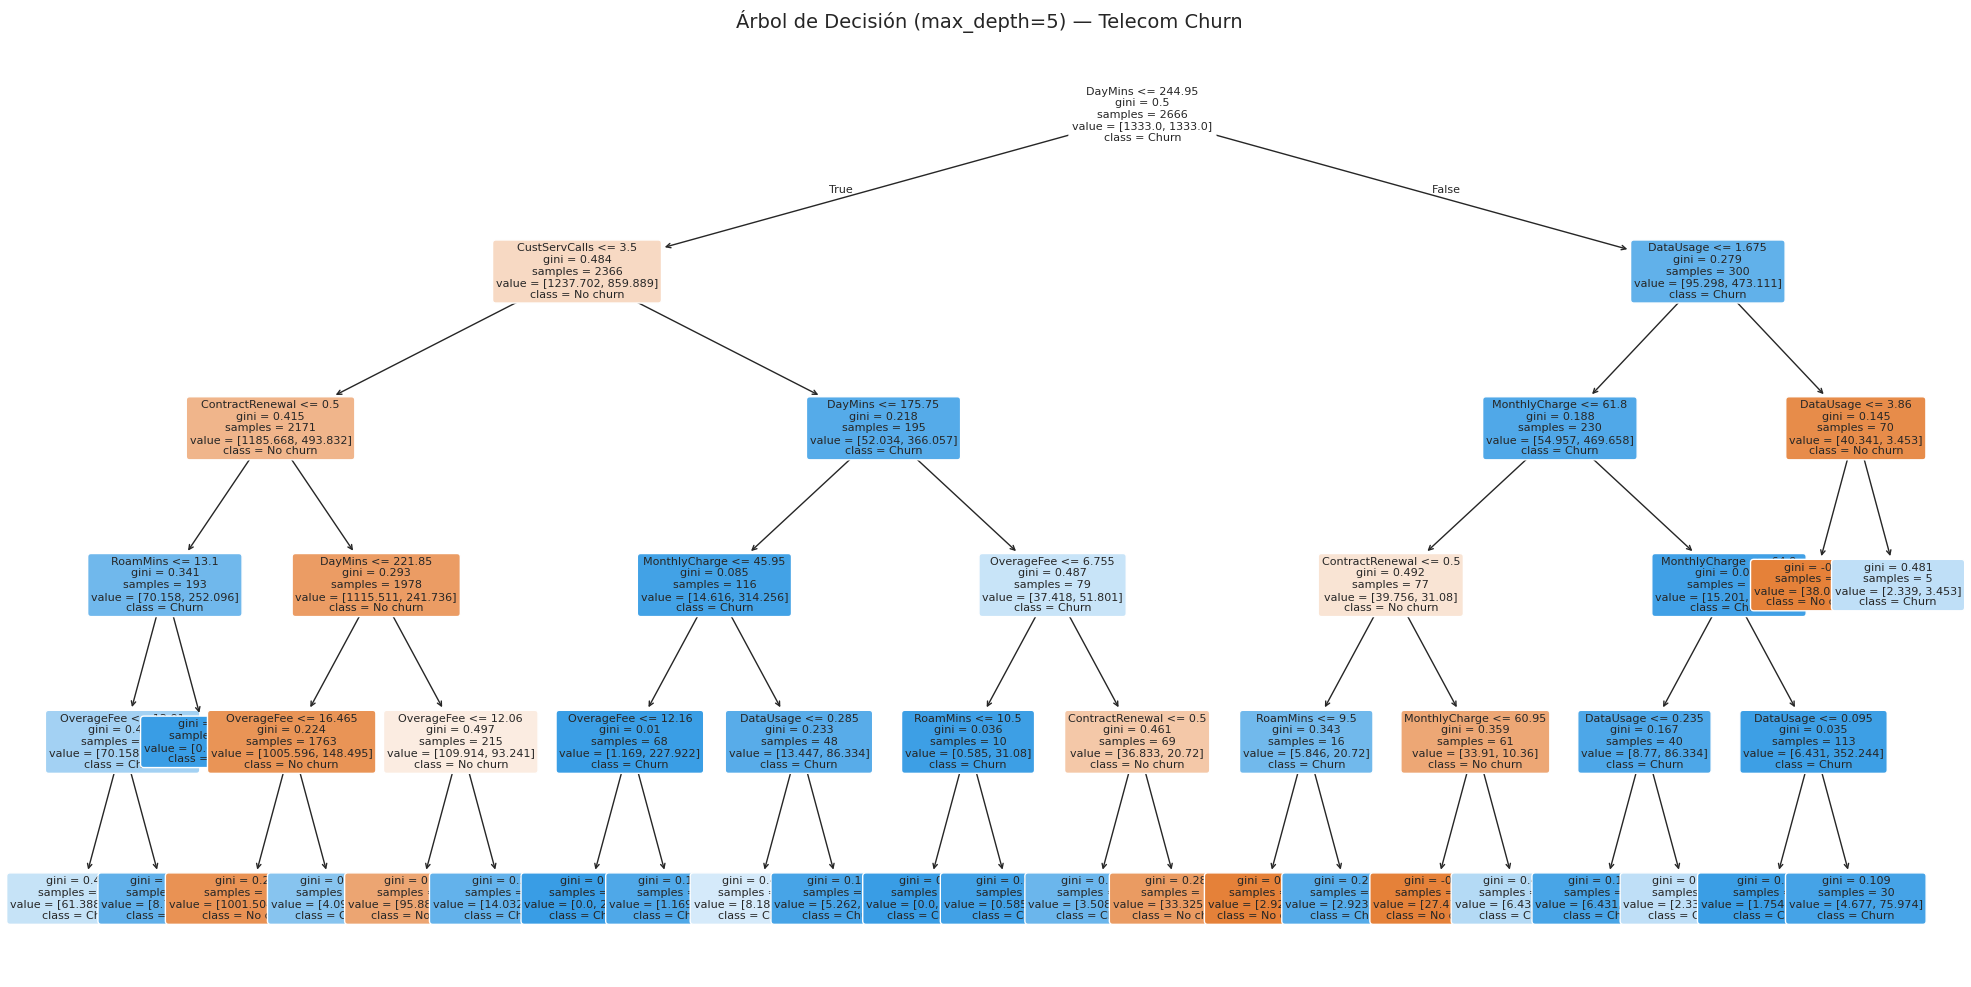

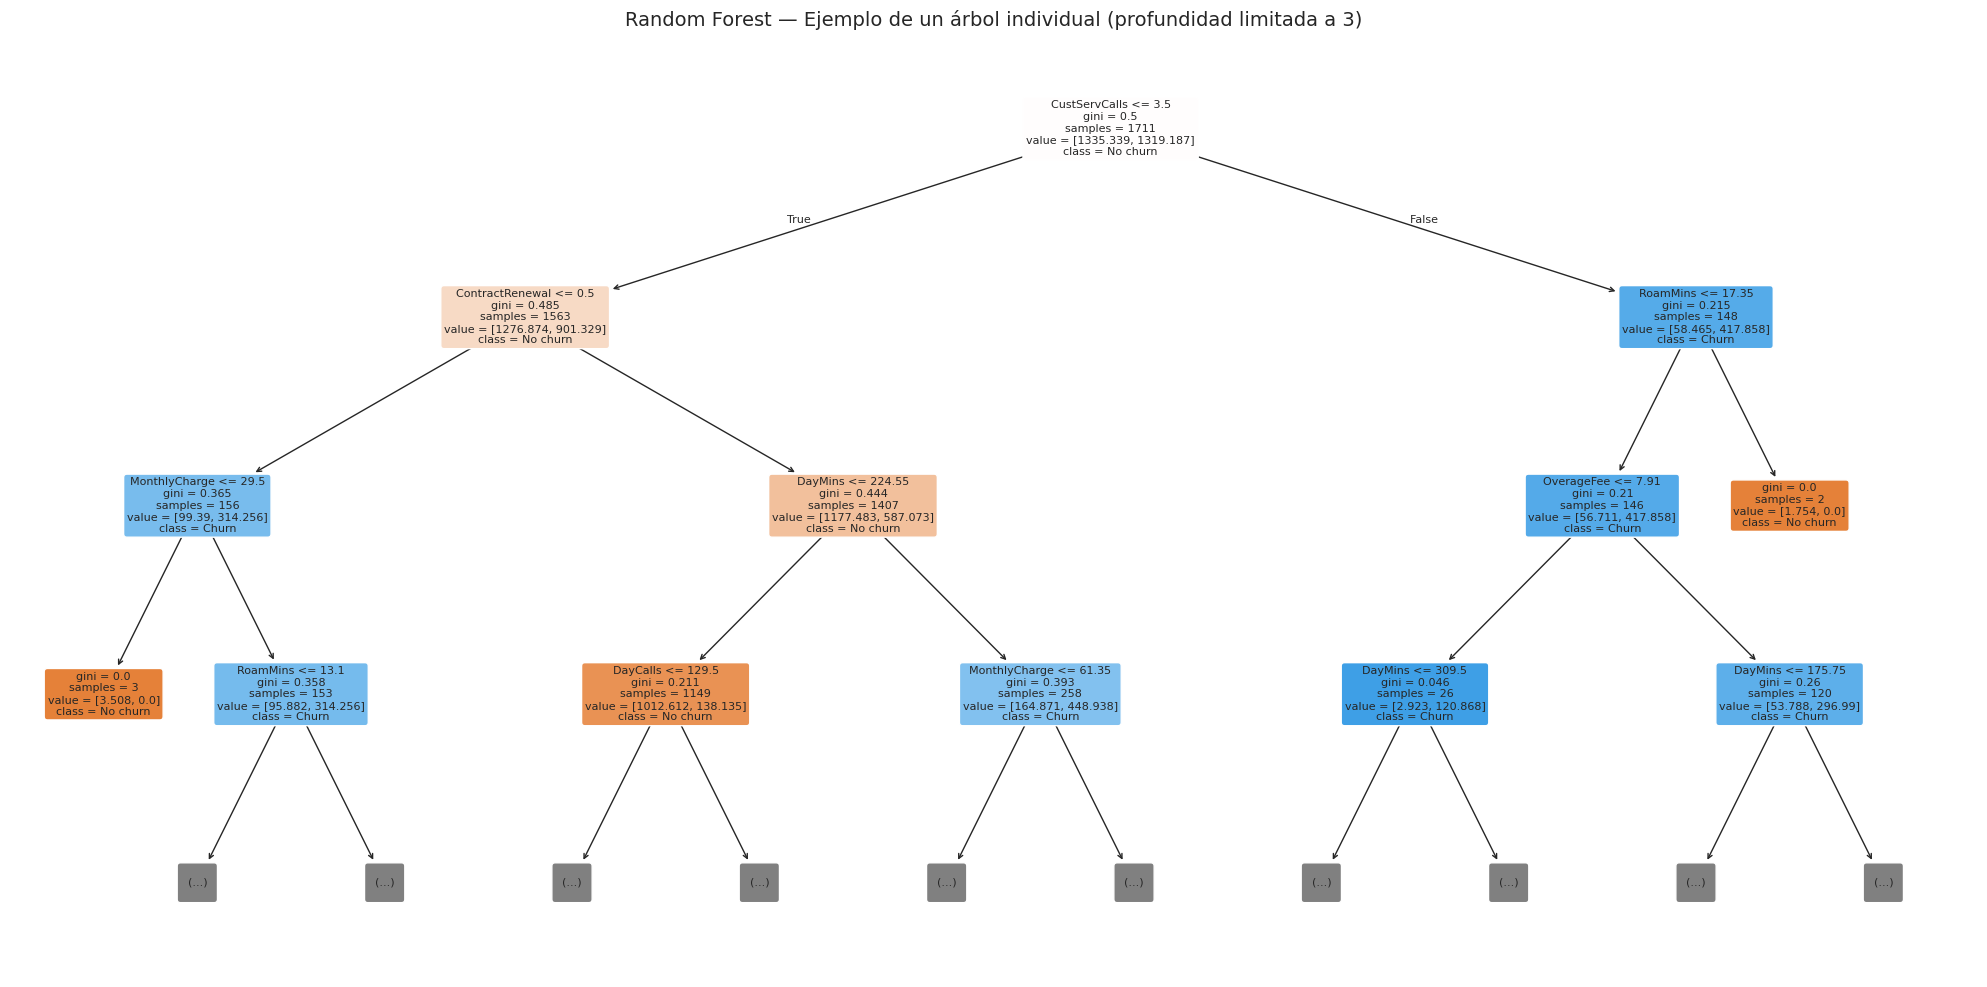

In [24]:
# Árbol de Decisión
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(models['Árbol de Decisión'].named_steps['clf'],
          feature_names=X.columns,
          class_names=['No churn', 'Churn'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión (max_depth=5) — Telecom Churn', fontsize=14)
plt.tight_layout()
plt.show()

# Un árbol individual del Random Forest (a modo ilustrativo)
rf_model = models['Random Forest'].named_steps['clf']
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(rf_model.estimators_[0],
          feature_names=X.columns,
          class_names=['No churn', 'Churn'],
          filled=True, rounded=True, fontsize=8, ax=ax,
          max_depth=3)  # limitamos la profundidad mostrada para que sea legible
ax.set_title('Random Forest — Ejemplo de un árbol individual (profundidad limitada a 3)', fontsize=14)
plt.tight_layout()
plt.show()

**Paso 10 — Evaluación completa de cada modelo.** Usamos la función eval_classifier (ya definida en tu notebook original) para obtener métricas, matriz de confusión y reporte de clasificación de cada uno de los 5 modelos.


=== Regresión Logística ===
  Accuracy: 0.7601
  Precision: 0.3478
  Recall: 0.7423
  F1-Score: 0.4737


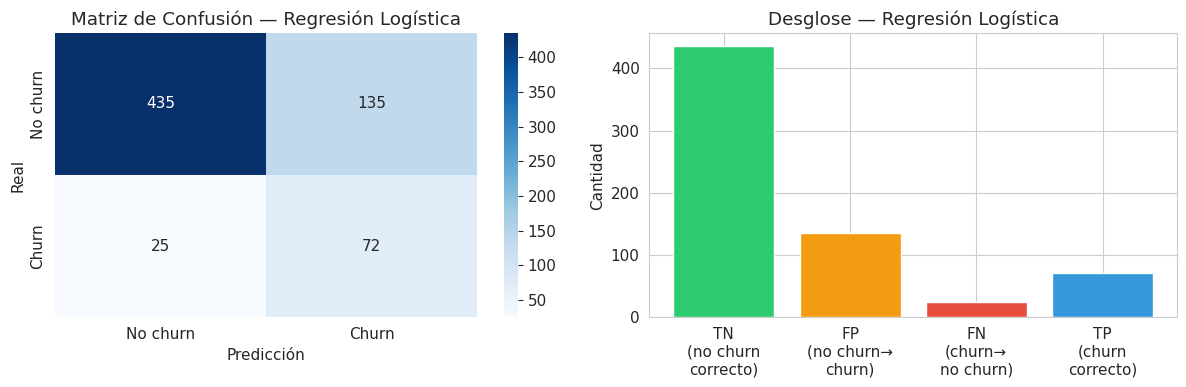


  FN (churn no detectado): 25
  FP (no churn predicho como churn): 135

Reporte completo:
              precision    recall  f1-score   support

    No churn       0.95      0.76      0.84       570
       Churn       0.35      0.74      0.47        97

    accuracy                           0.76       667
   macro avg       0.65      0.75      0.66       667
weighted avg       0.86      0.76      0.79       667


=== Árbol de Decisión ===
  Accuracy: 0.8546
  Precision: 0.5000
  Recall: 0.7732
  F1-Score: 0.6073


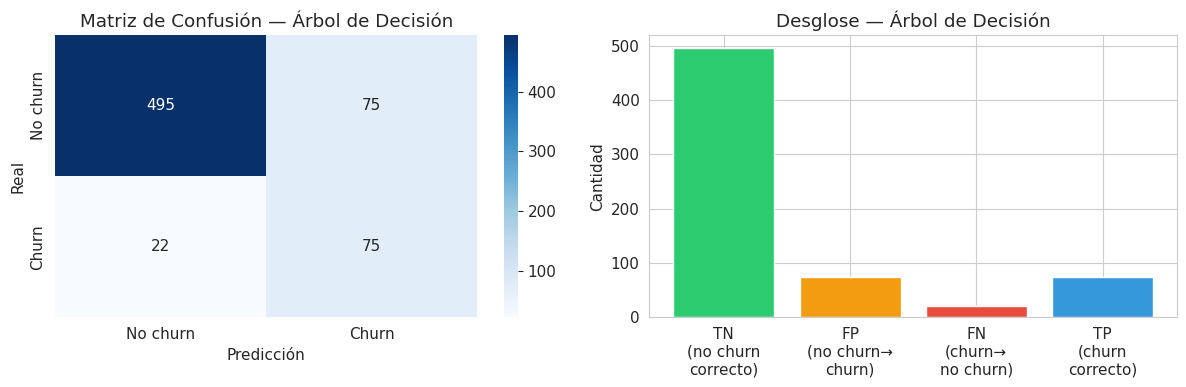


  FN (churn no detectado): 22
  FP (no churn predicho como churn): 75

Reporte completo:
              precision    recall  f1-score   support

    No churn       0.96      0.87      0.91       570
       Churn       0.50      0.77      0.61        97

    accuracy                           0.85       667
   macro avg       0.73      0.82      0.76       667
weighted avg       0.89      0.85      0.87       667


=== SVM (RBF) ===
  Accuracy: 0.8441
  Precision: 0.4774
  Recall: 0.7629
  F1-Score: 0.5873


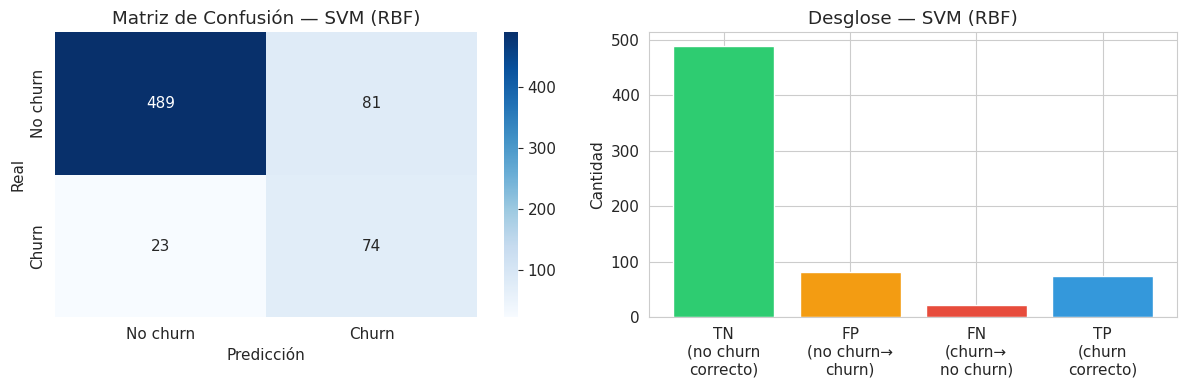


  FN (churn no detectado): 23
  FP (no churn predicho como churn): 81

Reporte completo:
              precision    recall  f1-score   support

    No churn       0.96      0.86      0.90       570
       Churn       0.48      0.76      0.59        97

    accuracy                           0.84       667
   macro avg       0.72      0.81      0.75       667
weighted avg       0.89      0.84      0.86       667


=== KNN ===
  Accuracy: 0.8801
  Precision: 0.6441
  Recall: 0.3918
  F1-Score: 0.4872


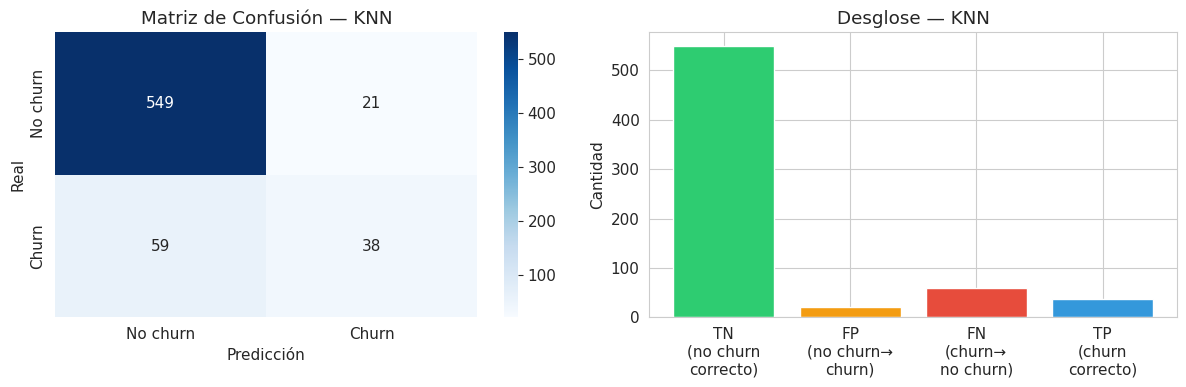


  FN (churn no detectado): 59
  FP (no churn predicho como churn): 21

Reporte completo:
              precision    recall  f1-score   support

    No churn       0.90      0.96      0.93       570
       Churn       0.64      0.39      0.49        97

    accuracy                           0.88       667
   macro avg       0.77      0.68      0.71       667
weighted avg       0.87      0.88      0.87       667


=== Random Forest ===
  Accuracy: 0.9010
  Precision: 0.6598
  Recall: 0.6598
  F1-Score: 0.6598


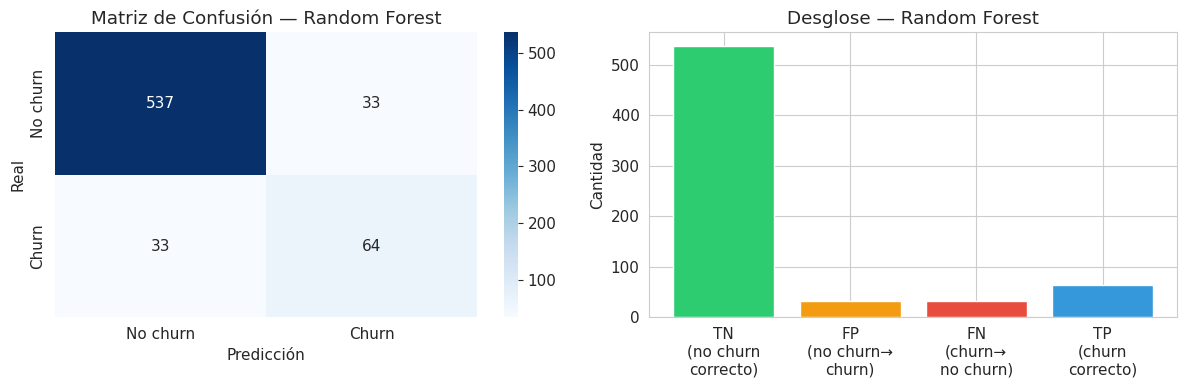


  FN (churn no detectado): 33
  FP (no churn predicho como churn): 33

Reporte completo:
              precision    recall  f1-score   support

    No churn       0.94      0.94      0.94       570
       Churn       0.66      0.66      0.66        97

    accuracy                           0.90       667
   macro avg       0.80      0.80      0.80       667
weighted avg       0.90      0.90      0.90       667



In [25]:
metrics_ej3 = {}

for name, model in models.items():
    print(f'\n{"="*50}')
    m = eval_classifier(model, X_train, y_train, X_test, y_test, name)
    metrics_ej3[name] = m

**Paso 11 — Tabla comparativa de métricas.** Consolidamos Accuracy, Precision, Recall, F1-Score y AUC de los 5 modelos en una sola tabla para facilitar la comparación.

In [26]:
all_metrics = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)

    all_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_val
    }

metrics_df = pd.DataFrame(all_metrics).T.round(4)
print('=== Tabla comparativa — Telecom Churn (Test Set) ===')
metrics_df

=== Tabla comparativa — Telecom Churn (Test Set) ===


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.7601,0.3478,0.7423,0.4737,0.8095
Árbol de Decisión,0.8546,0.5000,0.7732,0.6073,0.8352
SVM (RBF),0.8441,0.4774,0.7629,0.5873,0.8684
KNN,0.8801,0.6441,0.3918,0.4872,0.8112
Random Forest,0.9010,0.6598,0.6598,0.6598,0.8556


**Paso 12 — Curvas ROC superpuestas.** Graficamos las curvas ROC de los 5 modelos en un mismo gráfico para comparar visualmente su capacidad de discriminación (AUC).

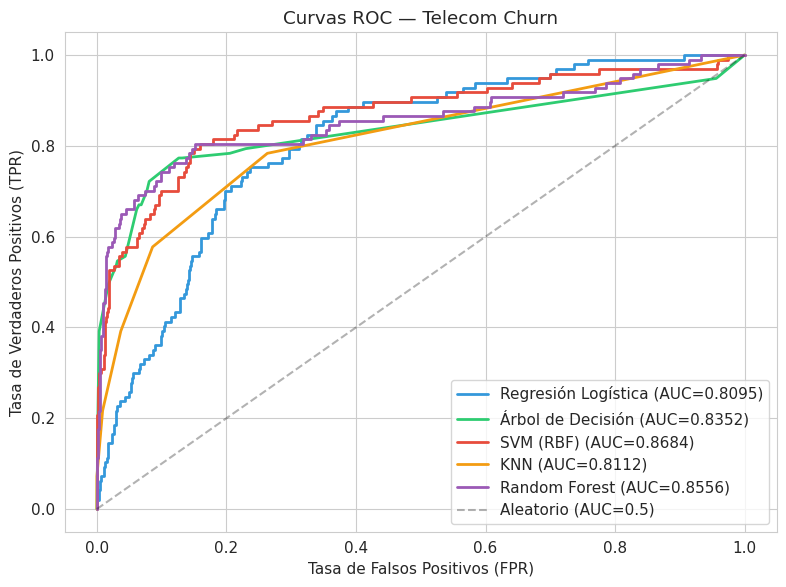

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for (name, model), color in zip(models.items(), colors_models):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f'{name} (AUC={roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Telecom Churn')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Paso 13 — Importancia de features del Random Forest.** Vemos qué variables pesan más en las decisiones del Random Forest, de forma análoga a como se hizo con el Árbol de Decisión en el ejemplo original.

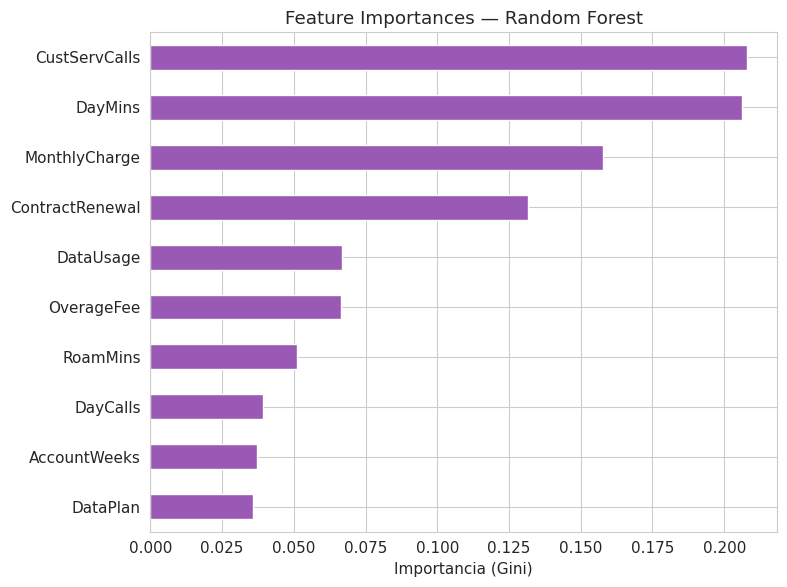

In [28]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='#9b59b6')
ax.set_title('Feature Importances — Random Forest')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

**Paso 14 — Matriz de selección de modelos.** Igual que en la sección 9.4 del ejemplo, resumimos cualitativamente las fortalezas de cada modelo en distintos criterios (precisión, velocidad, interpretabilidad, escalabilidad, robustez).

In [29]:
selection_matrix = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'Árbol de Decisión', 'SVM (RBF)', 'KNN', 'Random Forest'],
    'Precisión predictiva': ['★★★☆☆', '★★★☆☆', '★★★★☆', '★★★☆☆', '★★★★★'],
    'Velocidad (train+pred)': ['★★★★★', '★★★★☆', '★★★☆☆', '★★★★★', '★★★☆☆'],
    'Interpretabilidad': ['★★★★☆', '★★★★★', '★★☆☆☆', '★★★☆☆', '★★★☆☆'],
    'Escalabilidad': ['★★★★★', '★★★★☆', '★★☆☆☆', '★★☆☆☆', '★★★★☆'],
    'Robustez a outliers': ['★★★☆☆', '★★★★☆', '★★★★☆', '★★☆☆☆', '★★★★★']
}).set_index('Modelo')

print('=== Matriz de Selección de Modelos — Telecom Churn ===')
selection_matrix

=== Matriz de Selección de Modelos — Telecom Churn ===


,Precisión predictiva,Velocidad (train+pred),Interpretabilidad,Escalabilidad,Robustez a outliers
Modelo,,,,,
Reg. Logística,★★★☆☆,★★★★★,★★★★☆,★★★★★,★★★☆☆
Árbol de Decisión,★★★☆☆,★★★★☆,★★★★★,★★★★☆,★★★★☆
SVM (RBF),★★★★☆,★★★☆☆,★★☆☆☆,★★☆☆☆,★★★★☆
KNN,★★★☆☆,★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆
Random Forest,★★★★★,★★★☆☆,★★★☆☆,★★★★☆,★★★★★


**Paso 15 — Justificación del mejor modelo.** Cerramos identificando el mejor modelo según F1-Score y según Recall, y justificamos por qué Recall es la métrica más relevante en un problema de retención de clientes (evitar falsos negativos, es decir, clientes que se van sin ser detectados a tiempo).

In [30]:
best_model_name = metrics_df['F1-Score'].idxmax()
best_recall_name = metrics_df['Recall'].idxmax()

print('=== Conclusión — Telecom Churn ===')
print(f'\nMejor modelo por F1-Score: {best_model_name}')
print(f'Mejor modelo por Recall (clase churn): {best_recall_name}')
print(metrics_df.loc[[best_model_name]])
print('\nJustificación:')
print('  En un problema de retención de clientes, el costo de un Falso Negativo')
print('  (no detectar a un cliente que se va a ir) suele ser más alto que el de un')
print('  Falso Positivo (ofrecer una promoción a alguien que iba a quedarse).')
print('  Por eso, además del F1-Score, priorizamos Recall en la clase Churn.')
print(f'  El modelo "{best_recall_name}" es el candidato preferido para despliegue')
print('  si el objetivo principal es minimizar clientes perdidos sin detectar.')

=== Conclusión — Telecom Churn ===

Mejor modelo por F1-Score: Random Forest
Mejor modelo por Recall (clase churn): Árbol de Decisión
               Accuracy  Precision  Recall  F1-Score     AUC
Random Forest     0.901     0.6598  0.6598    0.6598  0.8556

Justificación:
  En un problema de retención de clientes, el costo de un Falso Negativo
  (no detectar a un cliente que se va a ir) suele ser más alto que el de un
  Falso Positivo (ofrecer una promoción a alguien que iba a quedarse).
  Por eso, además del F1-Score, priorizamos Recall en la clase Churn.
  El modelo "Árbol de Decisión" es el candidato preferido para despliegue
  si el objetivo principal es minimizar clientes perdidos sin detectar.
